In [2]:
import pandas as pd
import numpy as np

In [3]:
data_url = "http://jse.amstat.org/v19n3/decock/AmesHousing.txt"
columns = ['Overall Qual', 'Overall Cond', 'Gr Liv Area',
        'Central Air', 'Total Bsmt SF', 'SalePrice']
df = pd.read_csv(data_url, sep="\t", usecols=columns)
df.head()

,Overall Qual,Overall Cond,Total Bsmt SF,Central Air,Gr Liv Area,SalePrice
0,6,5,1080.0,Y,1656,215000
1,5,6,882.0,Y,896,105000
2,6,6,1329.0,Y,1329,172000
3,7,5,2110.0,Y,2110,244000
4,5,5,928.0,Y,1629,189900


In [4]:
df.shape

(2930, 6)

### Map central Air to number

- 'N':0
- 'Y':1

In [5]:
df['Central Air'] = df['Central Air'].map({'Y': 1, 'N': 0})

In [6]:
df.isnull().sum()

Overall Qual     0
Overall Cond     0
Total Bsmt SF    1
Central Air      0
Gr Liv Area      0
SalePrice        0
dtype: int64

In [7]:
# remove rows with missing values

df = df.dropna(axis=0)
df.isnull().sum()

Overall Qual     0
Overall Cond     0
Total Bsmt SF    0
Central Air      0
Gr Liv Area      0
SalePrice        0
dtype: int64

### Visualizing the characteristics of a dataset

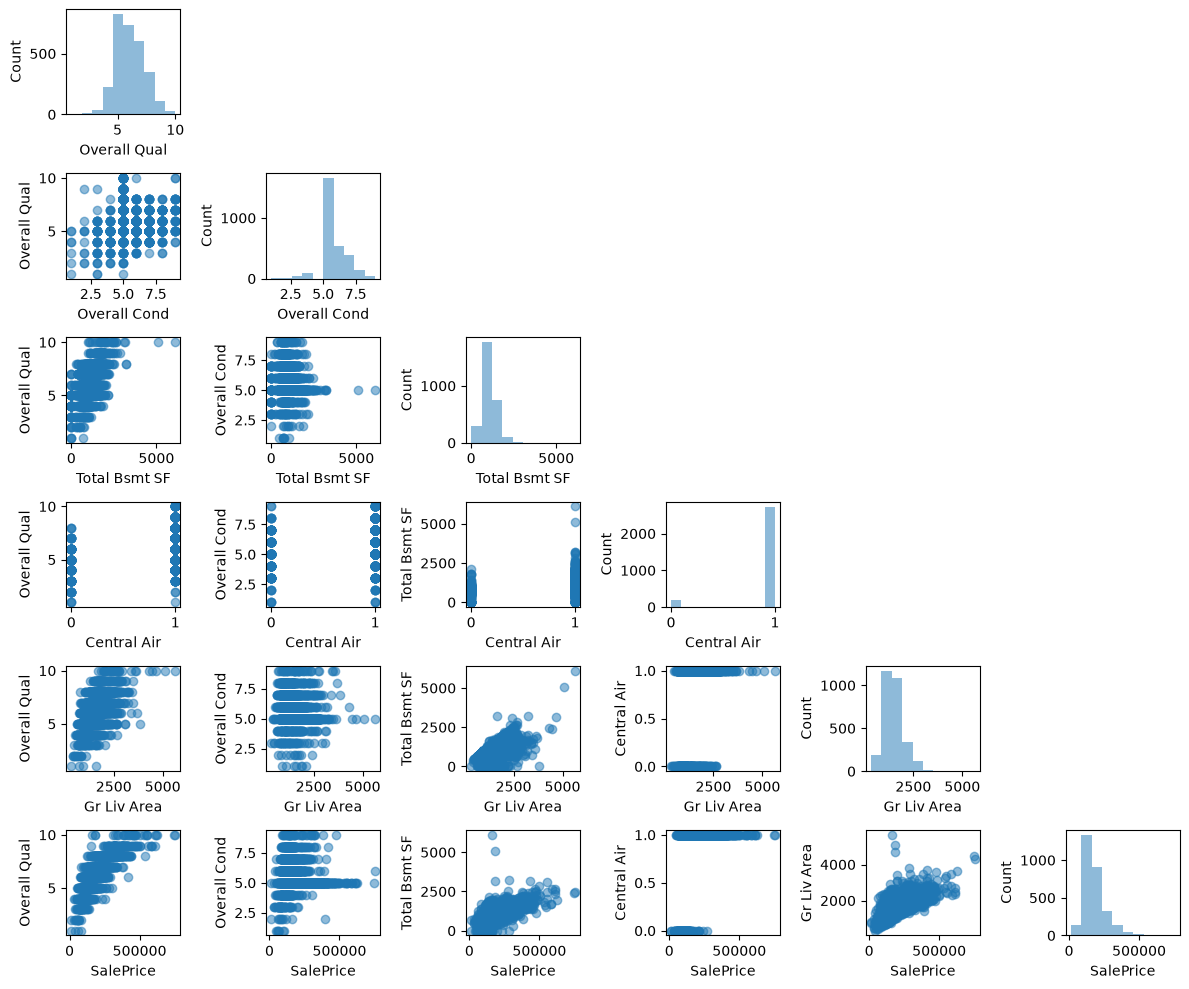

In [8]:
import matplotlib.pyplot as plt
from mlxtend.plotting import scatterplotmatrix

scatterplotmatrix(df.values, figsize=(12, 10), names=df.columns, alpha=0.5)
plt.tight_layout()
plt.show()

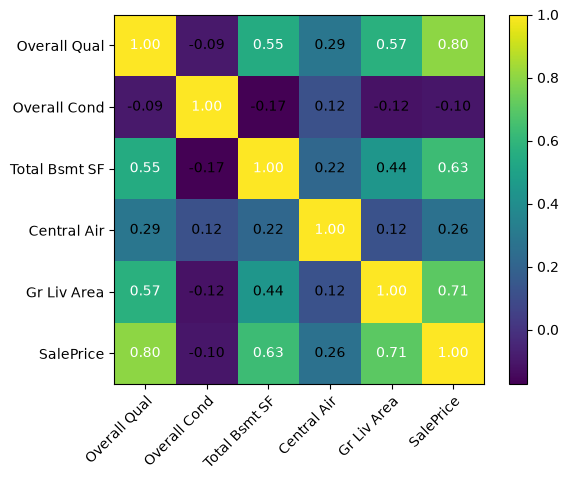

In [9]:
from mlxtend.plotting import heatmap
import numpy as np
cm = np.corrcoef(df.values.T)
heatmap(cm,
        row_names=df.columns,
        column_names=df.columns)
plt.show()

In [10]:
class LinearRegressionGD(object):
    def __init__(self, eta=0.001, n_iter=20):
        self.eta = eta
        self.n_iter = n_iter
    
    def fit(self, X, y):
        self.w_ = np.zeros(1 + X.shape[1])
        self.cost_ = []

        for i in range(self.n_iter):
            output = self.net_input(X)
            errors = (y - output)
            # Δwj​ = =η∑i​(y(i)−y^​(i))⋅xj(i)​
            self.w_[1:] += self.eta * X.T.dot(errors)
            # Δw0​ = η∑i​(y(i)−y^​(i))
            self.w_[0] += self.eta * errors.sum()
            # SSE = 1/2∑i​(y(i)−y^​(i))^2
            cost = (errors**2).sum() / 2.0
            self.cost_.append(cost)
        return self

    def net_input(self, X):
        return np.dot(X, self.w_[1:]) + self.w_[0]
    
    def predict(self, X):
        return self.net_input(X)

In [11]:
X = df[['Gr Liv Area']].values
y = df[['SalePrice']].values
print(f"X shape: {X.shape}, y shape: {y.shape}")
from sklearn.preprocessing import StandardScaler
sc_x = StandardScaler()
sc_y = StandardScaler()
X_std = sc_x.fit_transform(X)
# fit_transform() expects a 2D array, so we reshape y to be a 2D array with one column using y[:, np.newaxis]. After scaling, we flatten it back to a 1D array using .flatten().
y_std = sc_y.fit_transform(y).flatten()
lr = LinearRegressionGD(eta=0.0001)
lr.fit(X_std, y_std)


X shape: (2929, 1), y shape: (2929, 1)


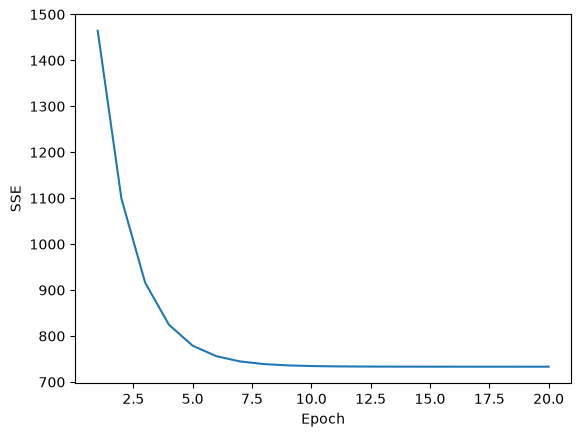

In [12]:
plt.plot(range(1, lr.n_iter + 1), lr.cost_)
plt.ylabel('SSE')
plt.xlabel('Epoch')
plt.show()

In [13]:
def lin_regplot(X, y, model):
    plt.scatter(X,y, c='steelblue', edgecolor='white', s=70)
    plt.plot(X, model.predict(X), color='black', lw=2)
    return None

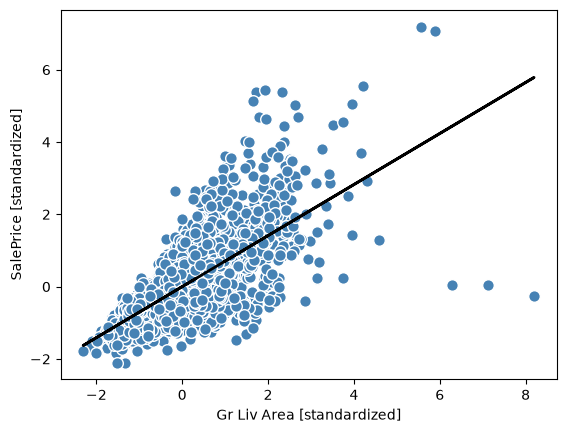

In [14]:
lin_regplot(X_std, y_std, lr)
plt.xlabel('Gr Liv Area [standardized]')
plt.ylabel('SalePrice [standardized]')
plt.show()

In [15]:
print(np.array([[2500]]).shape)
# [[2500]] 是二維 (1, 1)——1 個樣本、1 個特徵,符合 sklearn 的格式要求

(1, 1)


In [16]:
# 用的是 transform 而不是 fit_transform——必須沿用訓練資料算出的 μ 和 σ 來換算
feature_std = sc_x.transform(np.array([[2500]]))
target_std = lr.predict(feature_std)
target_reverted = sc_y.inverse_transform(target_std.reshape(-1, 1))
print(f'Sale price: ${target_reverted.flatten()[0]:.2f}')

Sale price: $292399.59


In [17]:
print(f"Slope: {lr.w_[1]:.3f}")
print(f"Intercept: {lr.w_[0]:.3f}")

Slope: 0.706
Intercept: -0.000


### Scikit-learn LinearRegression

In [27]:
from sklearn.linear_model import LinearRegression
slr = LinearRegression()
slr.fit(X, y)
y_pred = slr.predict(X)
print(f"Slope: {slr.coef_[0][0]:.3f}")
print(f"Intercept: {slr.intercept_[0]:.3f}")

Slope: 111.666
Intercept: 13342.979


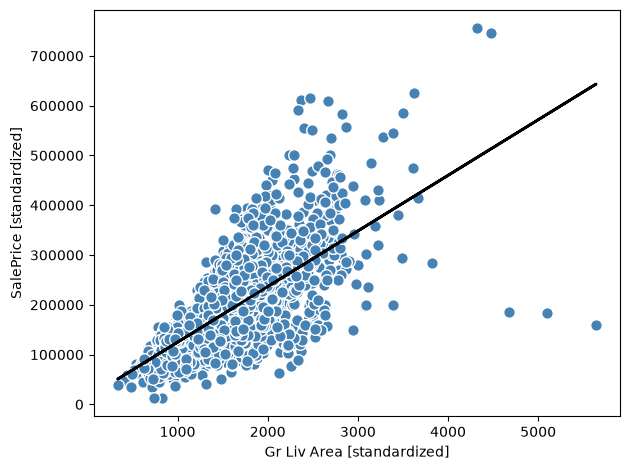

In [28]:
lin_regplot(X, y, slr)
plt.xlabel('Gr Liv Area [standardized]')
plt.ylabel('SalePrice [standardized]')
plt.tight_layout()
plt.show()